     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 5.7 MB/s eta 0:00:00

FORWARD TEST
Input: (2, 8, 512, 512)
Output: (2, 1, 512, 512)
Forward time: 2.348 sec

✓ Forward pass successful
✓ Quantum CPU/GPU boundary successful
✓ Batch-safe quantum execution successful

TRAINING - 100 EPOCHS

Epoch | TrainLoss | ValLoss | TrainAcc | ValAcc | TrainPrec | ValPrec | TrainRec | ValRec | TrainF1 | ValF1 | TrainIoU | ValIoU
------------------------------------------------------------------------------------------------------------------------------------------------------
001 | 0.8354 | 0.7672 | 0.8264 | 0.9172 | 0.2918 | 0.4214 | 0.5418 | 0.6894 | 0.3167 | 0.4732 | 0.2127 | 0.3326 ★  [92.9s]
002 | 0.7544 | 0.7348 | 0.8937 | 0.9022 | 0.4416 | 0.3849 | 0.7331 | 0.8268 | 0.5020 | 0.4805 | 0.3592 | 0.3366 ★  [55.5s]
003 | 0.7210 | 0.

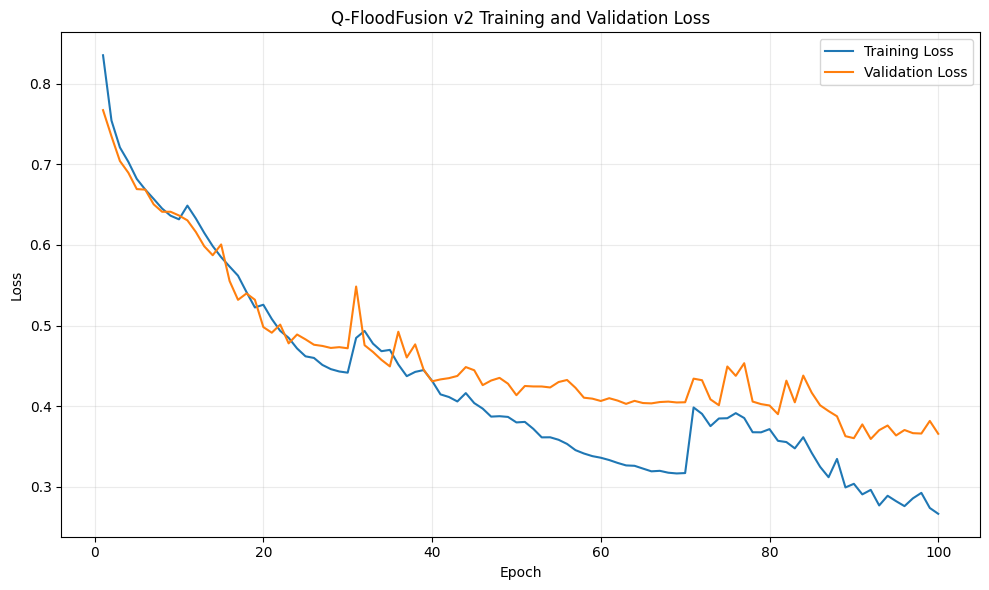

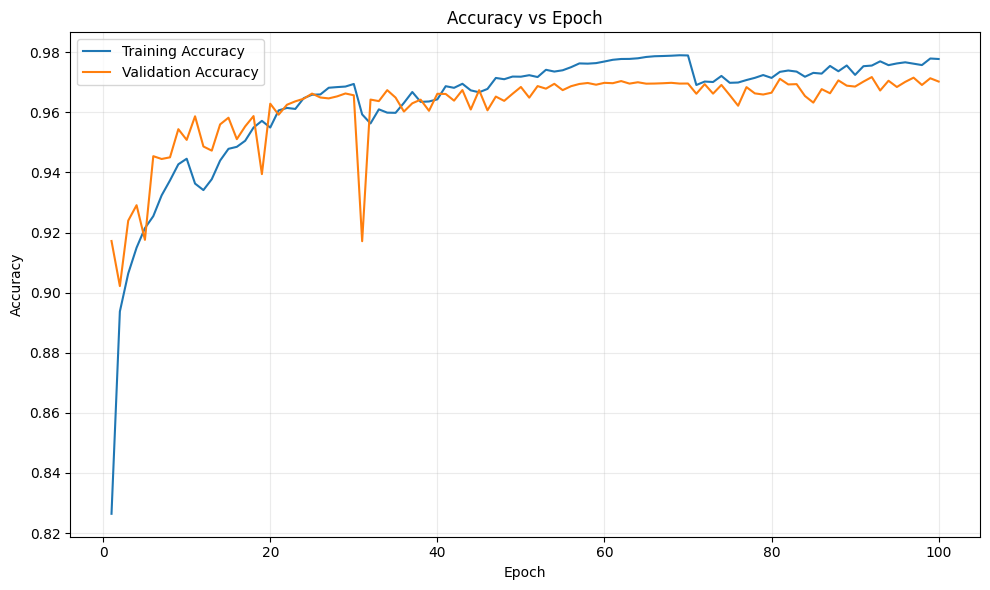

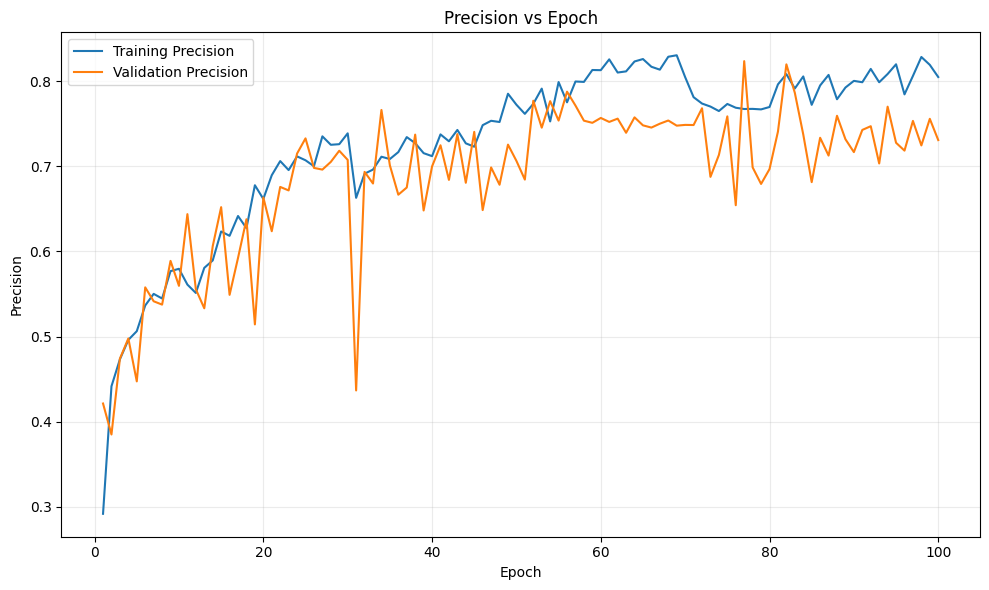

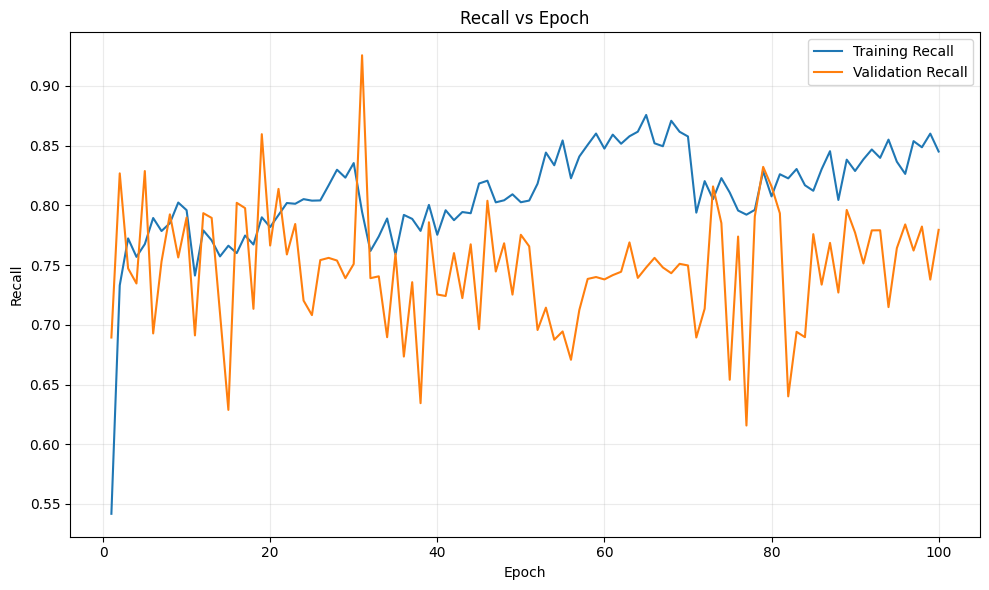

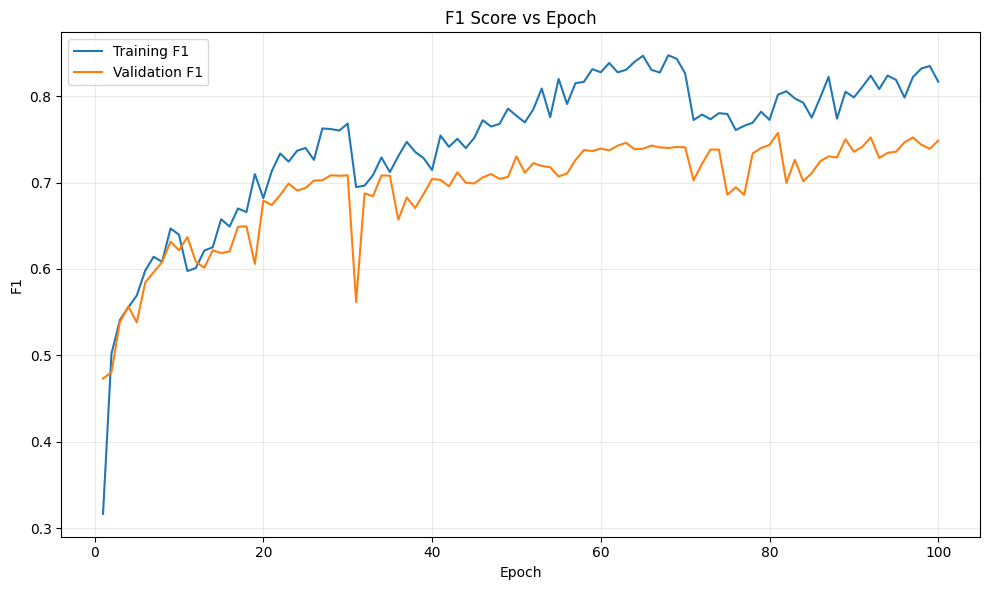

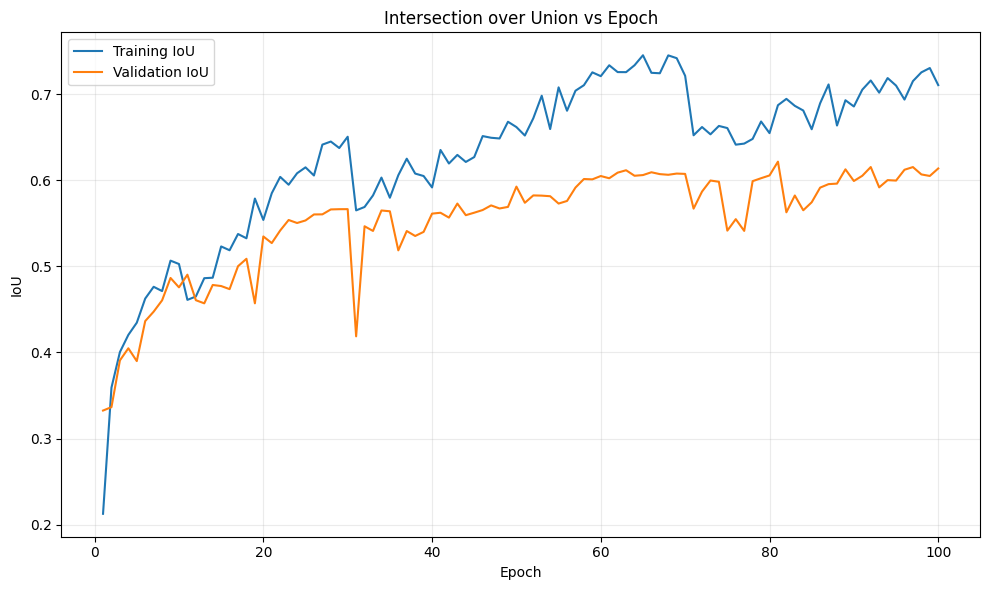

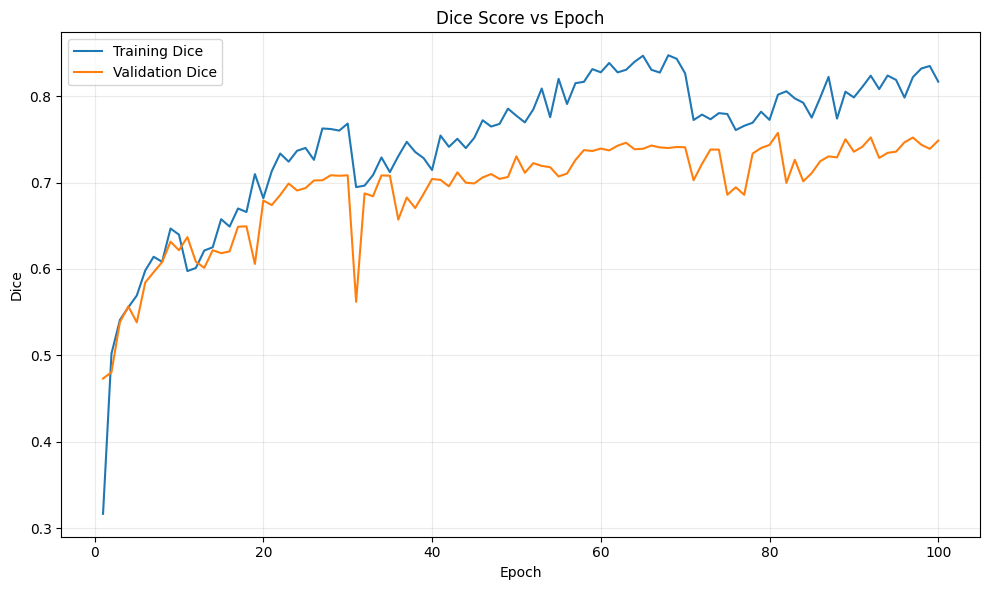

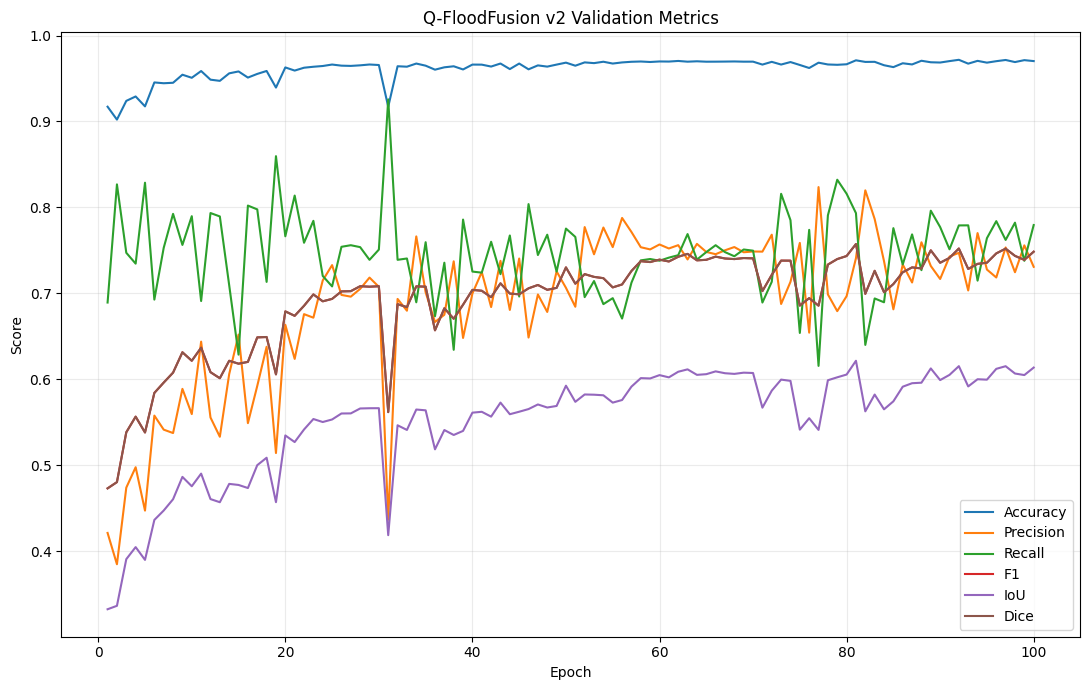

NameError: name 'image' is not defined

In [6]:
# ======================================================================
# Q-FLOODFUSION v2
# Quantum-Adaptive Multimodal Flood Segmentation
#
# FINAL SINGLE-CELL KAGGLE IMPLEMENTATION
#
# Dataset:
#   SEN1FLOODS11 - 8 Channel Remote Sensing Dataset
#
# Input channels:
#   0 = Sentinel-1 VV
#   1 = Sentinel-1 VH
#   2 = Sentinel-2 Green
#   3 = Sentinel-2 Red
#   4 = Sentinel-2 NIR
#   5 = Sentinel-2 SWIR
#   6 = DEM
#   7 = 7-day cumulative precipitation
#
# Architecture:
#
#   SAR STREAM
#       VV + VH
#           |
#      Residual Encoder
#           |
#      Channel Attention
#           |
#           |
#           +------------------+
#                              |
#   OPTICAL / ANCILLARY        |
#       S2 + DEM + Rain        |
#           |                  |
#      Residual Encoder        |
#           |                  |
#      Channel Attention       |
#           |                  |
#           +--------+---------+
#                    |
#             MULTI-SCALE FUSION
#                    |
#            Spatial Attention
#                    |
#              256-D bottleneck
#                    |
#             +------+------+
#             |             |
#       Classical      Quantum Branch
#       features       4-qubit VQC
#             |             |
#             |       Quantum embedding
#             |             |
#             +------+------+
#                    |
#          Quantum Adaptive Gating
#                    |
#             Attention Decoder
#                    |
#            Deep Supervision
#                    |
#             Flood Mask
#
# Quantum:
#   PennyLane default.qubit
#   CPU only
#
# Classical:
#   NVIDIA Tesla T4 / CUDA
#
# Training:
#   100 epochs
#   AMP
#   Tversky + Dice + Boundary loss
#   Cosine annealing
#   Validation threshold optimization
#
# ======================================================================


# ======================================================================
# 0. INSTALL DEPENDENCIES
# ======================================================================

import os
import sys
import glob
import random
import warnings
import subprocess
import time
import math
import copy

warnings.filterwarnings("ignore")

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pennylane",
        "rasterio",
        "scikit-learn",
        "fvcore"
    ],
    check=False
)


# ======================================================================
# 1. IMPORTS
# ======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import pennylane as qml

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix


# ======================================================================
# 2. GLOBAL CONFIGURATION
# ======================================================================

SEED = 42

EPOCHS = 100

BATCH_SIZE = 4

NUM_WORKERS = 2

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 20

NUM_QUBITS = 4

NUM_Q_LAYERS = 2

IMAGE_SIZE = 512


# ======================================================================
# 3. REPRODUCIBILITY
# ======================================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.benchmark = True


# ======================================================================
# 4. DEVICE
# ======================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 80)
print("Q-FLOODFUSION v2")
print("Quantum-Adaptive Multimodal Flood Segmentation")
print("=" * 80)

print()

print(
    "PyTorch version :",
    torch.__version__
)

print(
    "PennyLane       :",
    qml.__version__
)

print(
    "CUDA available  :",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM            :",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

print(
    "Classical device:",
    DEVICE
)


# ======================================================================
# 5. DATASET PATH
# ======================================================================

DATA_ROOT = (
    "/kaggle/input/datasets/"
    "oindrieelmondal/"
    "sen1floods11-8-channel-remote-sensing-dataset/"
    "dataset/"
    "Sen1Floods11_8Channel"
)

IMAGE_DIR = os.path.join(
    DATA_ROOT,
    "image"
)

LABEL_DIR = os.path.join(
    DATA_ROOT,
    "label"
)


print()
print("=" * 80)
print("DATASET")
print("=" * 80)

print(
    "Image directory:",
    IMAGE_DIR
)

print(
    "Label directory:",
    LABEL_DIR
)


if not os.path.isdir(IMAGE_DIR):

    raise FileNotFoundError(
        IMAGE_DIR
    )


if not os.path.isdir(LABEL_DIR):

    raise FileNotFoundError(
        LABEL_DIR
    )


# ======================================================================
# 6. FIND FILES
# ======================================================================

image_files = sorted(
    glob.glob(
        os.path.join(
            IMAGE_DIR,
            "*.tif"
        )
    )
)

label_files = sorted(
    glob.glob(
        os.path.join(
            LABEL_DIR,
            "*.tif"
        )
    )
)


def extract_id(path):

    return os.path.basename(
        path
    ).split("_")[0]


image_dict = {
    extract_id(p): p
    for p in image_files
}

label_dict = {
    extract_id(p): p
    for p in label_files
}


common_ids = sorted(
    set(image_dict)
    &
    set(label_dict)
)


pairs = [
    (
        image_dict[idx],
        label_dict[idx]
    )
    for idx in common_ids
]


print()

print(
    "Images found:",
    len(image_files)
)

print(
    "Labels found:",
    len(label_files)
)

print(
    "Matched pairs:",
    len(pairs)
)


if len(pairs) == 0:

    raise RuntimeError(
        "No matched image-label pairs found."
    )


# ======================================================================
# 7. DATASET VERIFICATION
# ======================================================================

sample_image_path, sample_label_path = pairs[0]


with rasterio.open(
    sample_image_path
) as src:

    sample_image = src.read()

    image_shape = sample_image.shape

    image_dtype = sample_image.dtype

    image_crs = src.crs


with rasterio.open(
    sample_label_path
) as src:

    sample_label = src.read()

    label_shape = sample_label.shape

    label_dtype = sample_label.dtype


print()
print("=" * 80)
print("DATASET VERIFICATION")
print("=" * 80)

print(
    "Image:",
    os.path.basename(sample_image_path)
)

print(
    "Image shape:",
    image_shape
)

print(
    "Image dtype:",
    image_dtype
)

print(
    "CRS:",
    image_crs
)

print()

print(
    "Label shape:",
    label_shape
)

print(
    "Label dtype:",
    label_dtype
)


if image_shape[0] != 8:

    raise RuntimeError(
        f"Expected 8 channels, got {image_shape[0]}"
    )


# ======================================================================
# 8. DATASET CLASS
# ======================================================================

class FloodDataset(Dataset):

    def __init__(
        self,
        pairs,
        augment=False
    ):

        self.pairs = pairs

        self.augment = augment


    def __len__(self):

        return len(self.pairs)


    # ------------------------------------------------------------------
    # ROBUST NORMALIZATION
    # ------------------------------------------------------------------

    def normalize(
        self,
        image
    ):

        image = image.astype(
            np.float32
        )

        output = np.zeros_like(
            image,
            dtype=np.float32
        )


        for c in range(
            image.shape[0]
        ):

            band = image[c]

            valid = np.isfinite(
                band
            )


            if not valid.any():

                continue


            values = band[valid]


            p2 = np.percentile(
                values,
                2
            )

            p98 = np.percentile(
                values,
                98
            )


            if p98 > p2:

                band = (
                    band - p2
                ) / (
                    p98 - p2 + 1e-8
                )

            else:

                band = np.zeros_like(
                    band
                )


            band = np.nan_to_num(
                band,
                nan=0.0,
                posinf=1.0,
                neginf=0.0
            )


            band = np.clip(
                band,
                0.0,
                1.0
            )


            output[c] = band


        return output


    # ------------------------------------------------------------------
    # GET ITEM
    # ------------------------------------------------------------------

    def __getitem__(
        self,
        idx
    ):

        image_path, label_path = self.pairs[idx]


        with rasterio.open(
            image_path
        ) as src:

            image = src.read()


        with rasterio.open(
            label_path
        ) as src:

            label = src.read(1)


        image = self.normalize(
            image
        )


        label = (
            label > 0
        ).astype(
            np.float32
        )


        # ==============================================================
        # AUGMENTATION
        # ==============================================================

        if self.augment:

            # Horizontal flip
            if random.random() < 0.5:

                image = np.flip(
                    image,
                    axis=2
                ).copy()

                label = np.flip(
                    label,
                    axis=1
                ).copy()


            # Vertical flip
            if random.random() < 0.5:

                image = np.flip(
                    image,
                    axis=1
                ).copy()

                label = np.flip(
                    label,
                    axis=0
                ).copy()


            # Rotation
            if random.random() < 0.5:

                k = random.randint(
                    1,
                    3
                )

                image = np.rot90(
                    image,
                    k=k,
                    axes=(1, 2)
                ).copy()

                label = np.rot90(
                    label,
                    k=k,
                    axes=(0, 1)
                ).copy()


            # Small Gaussian noise
            if random.random() < 0.20:

                noise = np.random.normal(
                    0,
                    0.01,
                    image.shape
                ).astype(
                    np.float32
                )

                image = np.clip(
                    image + noise,
                    0,
                    1
                )


        image = torch.from_numpy(
            image.copy()
        ).float()


        label = torch.from_numpy(
            label.copy()
        ).float().unsqueeze(0)


        return image, label


# ======================================================================
# 9. DATA SPLIT
# ======================================================================

train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.30,
    random_state=SEED
)


val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=SEED
)


print()
print("=" * 80)
print("DATA SPLIT")
print("=" * 80)

print(
    "Total:",
    len(pairs)
)

print(
    "Train:",
    len(train_pairs)
)

print(
    "Validation:",
    len(val_pairs)
)

print(
    "Test:",
    len(test_pairs)
)


# ======================================================================
# 10. DATASETS
# ======================================================================

train_dataset = FloodDataset(
    train_pairs,
    augment=True
)


val_dataset = FloodDataset(
    val_pairs,
    augment=False
)


test_dataset = FloodDataset(
    test_pairs,
    augment=False
)


# ======================================================================
# 11. DATALOADERS
# ======================================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# ======================================================================
# 12. VERIFY SAMPLE
# ======================================================================

sx, sy = train_dataset[0]


print()
print("=" * 80)
print("SAMPLE")
print("=" * 80)

print(
    "Input:",
    tuple(sx.shape)
)

print(
    "Mask:",
    tuple(sy.shape)
)

print(
    "Input range:",
    float(sx.min()),
    "->",
    float(sx.max())
)

print(
    "Flood pixels:",
    int(sy.sum())
)


# ======================================================================
# 13. BASIC CONVOLUTION
# ======================================================================

class ConvGNAct(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3
    ):

        super().__init__()


        padding = kernel_size // 2


        groups = min(
            8,
            out_channels
        )


        while (
            out_channels % groups != 0
            and groups > 1
        ):

            groups -= 1


        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                padding=padding,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.GELU()
        )


    def forward(
        self,
        x
    ):

        return self.block(x)


# ======================================================================
# 14. RESIDUAL BLOCK
# ======================================================================

class ResidualBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        dilation=1
    ):

        super().__init__()


        groups = min(
            8,
            out_channels
        )


        while (
            out_channels % groups != 0
            and groups > 1
        ):

            groups -= 1


        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            padding=dilation,
            dilation=dilation,
            bias=False
        )


        self.norm1 = nn.GroupNorm(
            groups,
            out_channels
        )


        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding=dilation,
            dilation=dilation,
            bias=False
        )


        self.norm2 = nn.GroupNorm(
            groups,
            out_channels
        )


        self.act = nn.GELU()


        if in_channels != out_channels:

            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                1,
                bias=False
            )

        else:

            self.skip = nn.Identity()


    def forward(
        self,
        x
    ):

        identity = self.skip(
            x
        )


        out = self.conv1(
            x
        )

        out = self.norm1(
            out
        )

        out = self.act(
            out
        )


        out = self.conv2(
            out
        )

        out = self.norm2(
            out
        )


        out = out + identity

        out = self.act(
            out
        )


        return out


# ======================================================================
# 15. CHANNEL ATTENTION
# ======================================================================

class ChannelAttention(nn.Module):

    def __init__(
        self,
        channels,
        reduction=8
    ):

        super().__init__()


        hidden = max(
            channels // reduction,
            8
        )


        self.avg_pool = nn.AdaptiveAvgPool2d(
            1
        )


        self.max_pool = nn.AdaptiveMaxPool2d(
            1
        )


        self.mlp = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                1,
                bias=False
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden,
                channels,
                1,
                bias=False
            )
        )


        self.sigmoid = nn.Sigmoid()


    def forward(
        self,
        x
    ):

        avg = self.mlp(
            self.avg_pool(x)
        )


        mx = self.mlp(
            self.max_pool(x)
        )


        attention = self.sigmoid(
            avg + mx
        )


        return x * attention


# ======================================================================
# 16. SPATIAL ATTENTION
# ======================================================================

class SpatialAttention(nn.Module):

    def __init__(
        self,
        kernel_size=7
    ):

        super().__init__()


        padding = kernel_size // 2


        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=padding,
            bias=False
        )


        self.sigmoid = nn.Sigmoid()


    def forward(
        self,
        x
    ):

        avg = torch.mean(
            x,
            dim=1,
            keepdim=True
        )


        mx = torch.max(
            x,
            dim=1,
            keepdim=True
        )[0]


        combined = torch.cat(
            [
                avg,
                mx
            ],
            dim=1
        )


        attention = self.sigmoid(
            self.conv(
                combined
            )
        )


        return x * attention


# ======================================================================
# 17. CBAM BLOCK
# ======================================================================

class CBAM(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        self.channel = ChannelAttention(
            channels
        )


        self.spatial = SpatialAttention()


    def forward(
        self,
        x
    ):

        x = self.channel(
            x
        )

        x = self.spatial(
            x
        )

        return x


# ======================================================================
# 18. MULTI-SCALE CONTEXT MODULE
# ======================================================================

class MultiScaleContext(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        branch_channels = channels // 4


        self.b1 = ConvGNAct(
            channels,
            branch_channels,
            3
        )


        self.b2 = ConvGNAct(
            channels,
            branch_channels,
            3
        )


        self.b3 = ConvGNAct(
            channels,
            branch_channels,
            3
        )


        self.b4 = ConvGNAct(
            channels,
            branch_channels,
            3
        )


        self.b2.block[0].dilation = (
            2,
            2
        )

        self.b2.block[0].padding = (
            2,
            2
        )


        self.b3.block[0].dilation = (
            4,
            4
        )

        self.b3.block[0].padding = (
            4,
            4
        )


        self.b4.block[0].dilation = (
            8,
            8
        )

        self.b4.block[0].padding = (
            8,
            8
        )


        self.fuse = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                channels
            ),

            nn.GELU()
        )


    def forward(
        self,
        x
    ):

        a = self.b1(x)

        b = self.b2(x)

        c = self.b3(x)

        d = self.b4(x)


        out = torch.cat(
            [
                a,
                b,
                c,
                d
            ],
            dim=1
        )


        return self.fuse(
            out
        )


# ======================================================================
# 19. ATTENTION GATE FOR DECODER
# ======================================================================

class AttentionGate(nn.Module):

    def __init__(
        self,
        gating_channels,
        skip_channels,
        inter_channels
    ):

        super().__init__()


        self.gate = nn.Sequential(

            nn.Conv2d(
                gating_channels,
                inter_channels,
                1,
                bias=False
            ),

            nn.GroupNorm(
                min(
                    8,
                    inter_channels
                ),
                inter_channels
            )
        )


        self.skip = nn.Sequential(

            nn.Conv2d(
                skip_channels,
                inter_channels,
                1,
                bias=False
            ),

            nn.GroupNorm(
                min(
                    8,
                    inter_channels
                ),
                inter_channels
            )
        )


        self.psi = nn.Sequential(

            nn.Conv2d(
                inter_channels,
                1,
                1
            ),

            nn.Sigmoid()
        )


        self.act = nn.GELU()


    def forward(
        self,
        g,
        x
    ):

        g1 = self.gate(
            g
        )


        x1 = self.skip(
            x
        )


        if g1.shape[2:] != x1.shape[2:]:

            g1 = F.interpolate(
                g1,
                size=x1.shape[2:],
                mode="bilinear",
                align_corners=False
            )


        attention = self.psi(
            self.act(
                g1 + x1
            )
        )


        return x * attention


# ======================================================================
# 20. ATTENTION DECODER BLOCK
# ======================================================================

class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()


        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            2,
            stride=2
        )


        self.attention = AttentionGate(
            out_channels,
            skip_channels,
            out_channels // 2
        )


        self.conv = ResidualBlock(
            out_channels + skip_channels,
            out_channels
        )


    def forward(
        self,
        x,
        skip
    ):

        x = self.up(
            x
        )


        if x.shape[2:] != skip.shape[2:]:

            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="bilinear",
                align_corners=False
            )


        skip = self.attention(
            x,
            skip
        )


        x = torch.cat(
            [
                x,
                skip
            ],
            dim=1
        )


        return self.conv(
            x
        )


# ======================================================================
# 21. QUANTUM CIRCUIT
# ======================================================================

Q_DEVICE = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


@qml.qnode(
    Q_DEVICE,
    interface="torch",
    diff_method="backprop"
)
def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------------
    # DATA ENCODING
    # --------------------------------------------------------------

    for i in range(
        NUM_QUBITS
    ):

        qml.RY(
            inputs[i],
            wires=i
        )

        qml.RZ(
            inputs[i],
            wires=i
        )


    # --------------------------------------------------------------
    # VARIATIONAL LAYERS
    # --------------------------------------------------------------

    for layer in range(
        NUM_Q_LAYERS
    ):

        for i in range(
            NUM_QUBITS
        ):

            qml.RX(
                weights[
                    layer,
                    i,
                    0
                ],
                wires=i
            )

            qml.RY(
                weights[
                    layer,
                    i,
                    1
                ],
                wires=i
            )

            qml.RZ(
                weights[
                    layer,
                    i,
                    2
                ],
                wires=i
            )


        # Ring entanglement

        for i in range(
            NUM_QUBITS
        ):

            qml.CNOT(
                wires=[
                    i,
                    (i + 1) % NUM_QUBITS
                ]
            )


    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(
            NUM_QUBITS
        )
    ]


weight_shapes = {

    "weights": (
        NUM_Q_LAYERS,
        NUM_QUBITS,
        3
    )
}


quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


quantum_layer = quantum_layer.to(
    "cpu"
)


# ======================================================================
# 22. Q-FLOODFUSION v2 MODEL
# ======================================================================

class QFloodFusionV2(nn.Module):

    def __init__(
        self
    ):

        super().__init__()


        # ==============================================================
        # SAR STREAM
        #
        # VV + VH
        # ==============================================================

        self.sar1 = ResidualBlock(
            2,
            32
        )


        self.sar2 = ResidualBlock(
            32,
            64
        )


        self.sar3 = ResidualBlock(
            64,
            128
        )


        self.sar_att = CBAM(
            128
        )


        # ==============================================================
        # OPTICAL + ANCILLARY STREAM
        #
        # S2 Green, Red, NIR, SWIR + DEM + precipitation
        # ==============================================================

        self.opt1 = ResidualBlock(
            6,
            32
        )


        self.opt2 = ResidualBlock(
            32,
            64
        )


        self.opt3 = ResidualBlock(
            64,
            128
        )


        self.opt_att = CBAM(
            128
        )


        # ==============================================================
        # SHARED DOWNSAMPLING
        # ==============================================================

        self.pool = nn.MaxPool2d(
            2
        )


        # ==============================================================
        # FUSION
        # ==============================================================

        self.fusion1 = ResidualBlock(
            256,
            256
        )


        self.fusion_att = CBAM(
            256
        )


        self.context = MultiScaleContext(
            256
        )


        # ==============================================================
        # QUANTUM PROJECTION
        # ==============================================================

        self.quantum_projection = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                1
            ),

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(
                0.15
            ),

            nn.Linear(
                128,
                NUM_QUBITS
            ),

            nn.Tanh()
        )


        # ==============================================================
        # QUANTUM LAYER
        # ==============================================================

        self.q_layer = quantum_layer


        # ==============================================================
        # QUANTUM ADAPTIVE GATE
        # ==============================================================

        self.quantum_gate = nn.Sequential(

            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.GELU(),

            nn.Linear(
                64,
                256
            ),

            nn.Sigmoid()
        )


        # ==============================================================
        # BOTTLENECK
        # ==============================================================

        self.bottleneck = ResidualBlock(
            256,
            256,
            dilation=2
        )


        self.bottleneck_att = CBAM(
            256
        )


        # ==============================================================
        # DECODER
        # ==============================================================

        self.dec3 = DecoderBlock(
            256,
            128,
            128
        )


        self.dec2 = DecoderBlock(
            128,
            64,
            64
        )


        self.dec1 = DecoderBlock(
            64,
            32,
            32
        )


        # ==============================================================
        # DEEP SUPERVISION HEADS
        # ==============================================================

        self.aux3 = nn.Conv2d(
            128,
            1,
            1
        )


        self.aux2 = nn.Conv2d(
            64,
            1,
            1
        )


        # ==============================================================
        # FINAL HEAD
        # ==============================================================

        self.head = nn.Sequential(

            nn.Conv2d(
                32,
                16,
                3,
                padding=1
            ),

            nn.GroupNorm(
                8,
                16
            ),

            nn.GELU(),

            nn.Conv2d(
                16,
                1,
                1
            )
        )


    # ==================================================================
    # FORWARD
    # ==================================================================

    def forward(
        self,
        x,
        return_aux=False
    ):

        # ==============================================================
        # INPUT
        # ==============================================================

        sar = x[
            :,
            0:2
        ]


        optical = x[
            :,
            2:8
        ]


        # ==============================================================
        # SAR ENCODER
        # ==============================================================

        s1 = self.sar1(
            sar
        )


        s2 = self.sar2(
            self.pool(s1)
        )


        s3 = self.sar3(
            self.pool(s2)
        )


        s3 = self.sar_att(
            s3
        )


        # ==============================================================
        # OPTICAL ENCODER
        # ==============================================================

        o1 = self.opt1(
            optical
        )


        o2 = self.opt2(
            self.pool(o1)
        )


        o3 = self.opt3(
            self.pool(o2)
        )


        o3 = self.opt_att(
            o3
        )


        # ==============================================================
        # MULTIMODAL FUSION
        # ==============================================================

        fused = torch.cat(
            [
                s3,
                o3
            ],
            dim=1
        )


        fused = self.fusion1(
            fused
        )


        fused = self.fusion_att(
            fused
        )


        # ==============================================================
        # MULTI-SCALE CONTEXT
        # ==============================================================

        context = self.context(
            fused
        )


        # ==============================================================
        # QUANTUM PROJECTION
        # ==============================================================

        q_input = self.quantum_projection(
            context
        )


        q_input = (
            q_input
            *
            math.pi
        )


        # ==============================================================
        # CPU QUANTUM EXECUTION
        # ==============================================================

        q_input_cpu = q_input.float().to(
            "cpu"
        )


        q_outputs = []


        for sample in q_input_cpu:

            q_out = self.q_layer(
                sample
            )

            q_outputs.append(
                q_out
            )


        q_features_cpu = torch.stack(
            q_outputs,
            dim=0
        )


        q_features = q_features_cpu.float().to(
            context.device
        )


        # ==============================================================
        # QUANTUM ADAPTIVE GATING
        # ==============================================================

        gate = self.quantum_gate(
            q_features
        )


        gate = gate.unsqueeze(
            -1
        ).unsqueeze(
            -1
        )


        # Quantum-modulated feature representation

        context = context * (
            1.0 + gate
        )


        # ==============================================================
        # BOTTLENECK
        # ==============================================================

        context = self.bottleneck(
            context
        )


        context = self.bottleneck_att(
            context
        )


        # ==============================================================
        # DECODER
        # ==============================================================

        d3 = self.dec3(
            context,
            s3
        )


        d2 = self.dec2(
            d3,
            s2
        )


        d1 = self.dec1(
            d2,
            s1
        )


        # ==============================================================
        # FINAL OUTPUT
        # ==============================================================

        logits = self.head(
            d1
        )


        logits = F.interpolate(
            logits,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        )


        if return_aux:

            aux3 = self.aux3(
                d3
            )


            aux3 = F.interpolate(
                aux3,
                size=x.shape[2:],
                mode="bilinear",
                align_corners=False
            )


            aux2 = self.aux2(
                d2
            )


            aux2 = F.interpolate(
                aux2,
                size=x.shape[2:],
                mode="bilinear",
                align_corners=False
            )


            return (
                logits,
                aux3,
                aux2
            )


        return logits


# ======================================================================
# 23. CREATE MODEL
# ======================================================================

model = QFloodFusionV2()


model = model.to(
    DEVICE
)


# IMPORTANT:
# Return quantum layer to CPU after model.to(cuda)

model.q_layer = model.q_layer.to(
    "cpu"
)


# ======================================================================
# 24. PARAMETER COUNT
# ======================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print()
print("=" * 80)
print("MODEL")
print("=" * 80)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Quantum parameter device:",
    sorted(
        set(
            str(p.device)
            for p in model.q_layer.parameters()
        )
    )
)


# ======================================================================
# 25. FORWARD TEST
# ======================================================================

bx, by = next(
    iter(train_loader)
)


test_input = bx[
    :2
].to(
    DEVICE,
    non_blocking=True
)


model.eval()


print()
print("=" * 80)
print("FORWARD TEST")
print("=" * 80)


with torch.no_grad():

    start = time.time()

    test_output = model(
        test_input
    )

    elapsed = (
        time.time()
        -
        start
    )


print(
    "Input:",
    tuple(test_input.shape)
)

print(
    "Output:",
    tuple(test_output.shape)
)

print(
    "Forward time:",
    f"{elapsed:.3f} sec"
)


expected = (
    test_input.shape[0],
    1,
    test_input.shape[2],
    test_input.shape[3]
)


if tuple(test_output.shape) != expected:

    raise RuntimeError(
        f"Output mismatch. "
        f"Expected {expected}, "
        f"got {tuple(test_output.shape)}"
    )


print()
print("✓ Forward pass successful")
print("✓ Quantum CPU/GPU boundary successful")
print("✓ Batch-safe quantum execution successful")


# ======================================================================
# 26. Tversky LOSS
# ======================================================================

def tversky_loss(
    logits,
    targets,
    alpha=0.35,
    beta=0.65,
    smooth=1.0
):

    probs = torch.sigmoid(
        logits
    )


    probs = probs.reshape(
        probs.shape[0],
        -1
    )


    targets = targets.reshape(
        targets.shape[0],
        -1
    )


    tp = (
        probs * targets
    ).sum(
        dim=1
    )


    fp = (
        probs *
        (1 - targets)
    ).sum(
        dim=1
    )


    fn = (
        (1 - probs) *
        targets
    ).sum(
        dim=1
    )


    score = (
        tp + smooth
    ) / (
        tp
        +
        alpha * fp
        +
        beta * fn
        +
        smooth
    )


    return (
        1.0 -
        score.mean()
    )


# ======================================================================
# 27. DICE LOSS
# ======================================================================

def dice_loss(
    logits,
    targets,
    smooth=1.0
):

    probs = torch.sigmoid(
        logits
    )


    probs = probs.reshape(
        probs.shape[0],
        -1
    )


    targets = targets.reshape(
        targets.shape[0],
        -1
    )


    intersection = (
        probs * targets
    ).sum(
        dim=1
    )


    dice = (
        2 * intersection
        +
        smooth
    ) / (
        probs.sum(dim=1)
        +
        targets.sum(dim=1)
        +
        smooth
    )


    return (
        1.0 -
        dice.mean()
    )


# ======================================================================
# 28. BOUNDARY LOSS
# ======================================================================

def boundary_loss(
    logits,
    targets
):

    probs = torch.sigmoid(
        logits
    )


    # Horizontal gradient

    pred_dx = torch.abs(
        probs[:, :, :, 1:]
        -
        probs[:, :, :, :-1]
    )


    true_dx = torch.abs(
        targets[:, :, :, 1:]
        -
        targets[:, :, :, :-1]
    )


    # Vertical gradient

    pred_dy = torch.abs(
        probs[:, :, 1:, :]
        -
        probs[:, :, :-1, :]
    )


    true_dy = torch.abs(
        targets[:, :, 1:, :]
        -
        targets[:, :, :-1, :]
    )


    loss_x = F.l1_loss(
        pred_dx,
        true_dx
    )


    loss_y = F.l1_loss(
        pred_dy,
        true_dy
    )


    return (
        loss_x
        +
        loss_y
    )


# ======================================================================
# 29. COMBINED LOSS
# ======================================================================

def segmentation_loss(
    logits,
    targets,
    aux3=None,
    aux2=None
):

    # Main losses

    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets
    )


    tv = tversky_loss(
        logits,
        targets
    )


    dice = dice_loss(
        logits,
        targets
    )


    boundary = boundary_loss(
        logits,
        targets
    )


    main = (
        0.20 * bce
        +
        0.35 * tv
        +
        0.30 * dice
        +
        0.15 * boundary
    )


    # --------------------------------------------------------------
    # DEEP SUPERVISION
    # --------------------------------------------------------------

    if aux3 is not None:

        aux_loss3 = (
            0.5 *
            dice_loss(
                aux3,
                targets
            )
            +
            0.5 *
            tversky_loss(
                aux3,
                targets
            )
        )

    else:

        aux_loss3 = 0.0


    if aux2 is not None:

        aux_loss2 = (
            0.5 *
            dice_loss(
                aux2,
                targets
            )
            +
            0.5 *
            tversky_loss(
                aux2,
                targets
            )
        )

    else:

        aux_loss2 = 0.0


    total = (
        main
        +
        0.15 * aux_loss3
        +
        0.10 * aux_loss2
    )


    return total


# ======================================================================
# 30. METRICS
# ======================================================================

@torch.no_grad()
def compute_metrics(
    logits,
    targets,
    threshold=0.5
):

    probs = torch.sigmoid(
        logits
    )


    predictions = (
        probs >= threshold
    ).float()


    targets = (
        targets >= 0.5
    ).float()


    predictions = predictions.reshape(
        -1
    )


    targets = targets.reshape(
        -1
    )


    tp = (
        (predictions == 1)
        &
        (targets == 1)
    ).sum().item()


    tn = (
        (predictions == 0)
        &
        (targets == 0)
    ).sum().item()


    fp = (
        (predictions == 1)
        &
        (targets == 0)
    ).sum().item()


    fn = (
        (predictions == 0)
        &
        (targets == 1)
    ).sum().item()


    eps = 1e-8


    accuracy = (
        tp + tn
    ) / (
        tp
        +
        tn
        +
        fp
        +
        fn
        +
        eps
    )


    precision = (
        tp
        /
        (
            tp
            +
            fp
            +
            eps
        )
    )


    recall = (
        tp
        /
        (
            tp
            +
            fn
            +
            eps
        )
    )


    f1 = (
        2 *
        precision *
        recall
    ) / (
        precision
        +
        recall
        +
        eps
    )


    iou = (
        tp
        /
        (
            tp
            +
            fp
            +
            fn
            +
            eps
        )
    )


    dice = (
        2 * tp
    ) / (
        2 * tp
        +
        fp
        +
        fn
        +
        eps
    )


    return {

        "accuracy":
            accuracy,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "iou":
            iou,

        "dice":
            dice
    }


# ======================================================================
# 31. THRESHOLD SEARCH
# ======================================================================

@torch.no_grad()
def find_best_threshold(
    model,
    loader
):

    model.eval()


    all_probs = []

    all_targets = []


    for images, masks in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        logits = model(
            images
        )


        probs = torch.sigmoid(
            logits
        ).detach().cpu()


        all_probs.append(
            probs
        )


        all_targets.append(
            masks.cpu()
        )


    all_probs = torch.cat(
        all_probs,
        dim=0
    )


    all_targets = torch.cat(
        all_targets,
        dim=0
    )


    best_threshold = 0.5

    best_f1 = -1

    best_iou = -1


    for threshold in np.arange(
        0.20,
        0.81,
        0.02
    ):

        metrics = compute_metrics(
            all_probs,
            all_targets,
            threshold=float(threshold)
        )


        # Primary selection: F1
        # Secondary: IoU

        if (
            metrics["f1"] > best_f1
            or
            (
                abs(
                    metrics["f1"]
                    -
                    best_f1
                ) < 1e-6
                and
                metrics["iou"] > best_iou
            )
        ):

            best_f1 = metrics["f1"]

            best_iou = metrics["iou"]

            best_threshold = float(
                threshold
            )


    return (
        best_threshold,
        best_f1,
        best_iou
    )


# ======================================================================
# 32. TRAIN ONE EPOCH
# ======================================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler
):

    model.train()


    loss_total = 0.0


    metric_totals = {

        "accuracy": 0.0,

        "precision": 0.0,

        "recall": 0.0,

        "f1": 0.0,

        "iou": 0.0,

        "dice": 0.0
    }


    batches = 0


    for images, masks in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        if torch.cuda.is_available():

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                logits, aux3, aux2 = model(
                    images,
                    return_aux=True
                )


                loss = segmentation_loss(
                    logits,
                    masks,
                    aux3,
                    aux2
                )

        else:

            logits, aux3, aux2 = model(
                images,
                return_aux=True
            )


            loss = segmentation_loss(
                logits,
                masks,
                aux3,
                aux2
            )


        # ----------------------------------------------------------
        # BACKWARD
        # ----------------------------------------------------------

        if scaler is not None:

            scaler.scale(
                loss
            ).backward()


            scaler.unscale_(
                optimizer
            )


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )


            scaler.step(
                optimizer
            )


            scaler.update()

        else:

            loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )


            optimizer.step()


        # ----------------------------------------------------------
        # METRICS
        # ----------------------------------------------------------

        metrics = compute_metrics(
            logits.float(),
            masks,
            threshold=0.5
        )


        loss_total += (
            loss.item()
        )


        for key in metric_totals:

            metric_totals[key] += (
                metrics[key]
            )


        batches += 1


    results = {

        "loss":
            loss_total / batches
    }


    for key in metric_totals:

        results[key] = (
            metric_totals[key]
            /
            batches
        )


    return results


# ======================================================================
# 33. VALIDATION
# ======================================================================

@torch.no_grad()
def validate(
    model,
    loader,
    threshold=0.5
):

    model.eval()


    loss_total = 0.0


    metric_totals = {

        "accuracy": 0.0,

        "precision": 0.0,

        "recall": 0.0,

        "f1": 0.0,

        "iou": 0.0,

        "dice": 0.0
    }


    batches = 0


    for images, masks in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True
        )


        logits, aux3, aux2 = model(
            images,
            return_aux=True
        )


        loss = segmentation_loss(
            logits,
            masks,
            aux3,
            aux2
        )


        metrics = compute_metrics(
            logits.float(),
            masks,
            threshold
        )


        loss_total += (
            loss.item()
        )


        for key in metric_totals:

            metric_totals[key] += (
                metrics[key]
            )


        batches += 1


    results = {

        "loss":
            loss_total / batches
    }


    for key in metric_totals:

        results[key] = (
            metric_totals[key]
            /
            batches
        )


    return results


# ======================================================================
# 34. OPTIMIZER
# ======================================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ======================================================================
# 35. COSINE SCHEDULER
# ======================================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6
)


# ======================================================================
# 36. AMP SCALER
# ======================================================================

if torch.cuda.is_available():

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None


# ======================================================================
# 37. TRAINING HISTORY
# ======================================================================

history = []


best_val_iou = -1.0

best_val_f1 = -1.0

best_state = None

best_epoch = 0

patience_counter = 0


# ======================================================================
# 38. TRAINING
# ======================================================================

print()
print("=" * 80)
print("TRAINING - 100 EPOCHS")
print("=" * 80)

print()

print(
    "Epoch | "
    "TrainLoss | "
    "ValLoss | "
    "TrainAcc | "
    "ValAcc | "
    "TrainPrec | "
    "ValPrec | "
    "TrainRec | "
    "ValRec | "
    "TrainF1 | "
    "ValF1 | "
    "TrainIoU | "
    "ValIoU"
)

print("-" * 150)


for epoch in range(
    1,
    EPOCHS + 1
):

    start_time = time.time()


    # --------------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------------

    train_results = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler
    )


    # --------------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------------

    val_results = validate(
        model,
        val_loader,
        threshold=0.5
    )


    # --------------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------------

    scheduler.step(
        epoch
    )


    # --------------------------------------------------------------
    # SAVE BEST
    # --------------------------------------------------------------

    improved = (

        val_results["iou"]
        >
        best_val_iou
    )


    if improved:

        best_val_iou = (
            val_results["iou"]
        )


        best_val_f1 = (
            val_results["f1"]
        )


        best_epoch = epoch


        best_state = {
            k:
            v.detach().cpu().clone()

            for k, v
            in model.state_dict().items()
        }


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_iou":
                    best_val_iou,

                "val_f1":
                    best_val_f1
            },

            "/kaggle/working/"
            "qfloodfusion_v2_best.pth"
        )


        patience_counter = 0

        marker = " ★"

    else:

        patience_counter += 1

        marker = ""


    # --------------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------------

    elapsed = (
        time.time()
        -
        start_time
    )


    history.append({

        "epoch":
            epoch,

        "train_loss":
            train_results["loss"],

        "val_loss":
            val_results["loss"],

        "train_accuracy":
            train_results["accuracy"],

        "val_accuracy":
            val_results["accuracy"],

        "train_precision":
            train_results["precision"],

        "val_precision":
            val_results["precision"],

        "train_recall":
            train_results["recall"],

        "val_recall":
            val_results["recall"],

        "train_f1":
            train_results["f1"],

        "val_f1":
            val_results["f1"],

        "train_iou":
            train_results["iou"],

        "val_iou":
            val_results["iou"],

        "train_dice":
            train_results["dice"],

        "val_dice":
            val_results["dice"],

        "learning_rate":
            optimizer.param_groups[0]["lr"],

        "epoch_time_sec":
            elapsed
    })


    # --------------------------------------------------------------
    # PRINT
    # --------------------------------------------------------------

    print(

        f"{epoch:03d} | "

        f"{train_results['loss']:.4f} | "

        f"{val_results['loss']:.4f} | "

        f"{train_results['accuracy']:.4f} | "

        f"{val_results['accuracy']:.4f} | "

        f"{train_results['precision']:.4f} | "

        f"{val_results['precision']:.4f} | "

        f"{train_results['recall']:.4f} | "

        f"{val_results['recall']:.4f} | "

        f"{train_results['f1']:.4f} | "

        f"{val_results['f1']:.4f} | "

        f"{train_results['iou']:.4f} | "

        f"{val_results['iou']:.4f}"

        f"{marker}"

        f"  [{elapsed:.1f}s]"
    )


    # --------------------------------------------------------------
    # PERIODIC CHECKPOINT
    # --------------------------------------------------------------

    if epoch % 10 == 0:

        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "history":
                    history
            },

            f"/kaggle/working/"
            f"qfloodfusion_v2_epoch_{epoch:03d}.pth"
        )


    # --------------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------------

    if (
        patience_counter
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            "Early stopping triggered at epoch",
            epoch
        )

        break


# ======================================================================
# 39. RESTORE BEST MODEL
# ======================================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )


print()
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation IoU:",
    f"{best_val_iou:.4f}"
)

print(
    "Best validation F1:",
    f"{best_val_f1:.4f}"
)


# ======================================================================
# 40. SAVE HISTORY
# ======================================================================

history_df = pd.DataFrame(
    history
)


history_csv = (
    "/kaggle/working/"
    "qfloodfusion_v2_training_history.csv"
)


history_df.to_csv(
    history_csv,
    index=False
)


# ======================================================================
# 41. FIND BEST VALIDATION THRESHOLD
# ======================================================================

print()
print("=" * 80)
print("VALIDATION THRESHOLD OPTIMIZATION")
print("=" * 80)


best_threshold, threshold_f1, threshold_iou = find_best_threshold(
    model,
    val_loader
)


print(
    "Optimal validation threshold:",
    f"{best_threshold:.2f}"
)

print(
    "Validation F1 at threshold:",
    f"{threshold_f1:.4f}"
)

print(
    "Validation IoU at threshold:",
    f"{threshold_iou:.4f}"
)


# ======================================================================
# 42. FINAL TEST
# ======================================================================

print()
print("=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)


test_results = validate(
    model,
    test_loader,
    threshold=best_threshold
)


for key, value in test_results.items():

    print(
        f"{key.capitalize():12s}: "
        f"{value:.4f}"
    )


# ======================================================================
# 43. TEST CONFUSION MATRIX
# ======================================================================

@torch.no_grad()
def collect_predictions(
    model,
    loader,
    threshold
):

    model.eval()


    all_predictions = []

    all_targets = []


    for images, masks in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        logits = model(
            images
        )


        probs = torch.sigmoid(
            logits
        )


        predictions = (
            probs >= threshold
        ).long()


        all_predictions.append(
            predictions.cpu().numpy().reshape(-1)
        )


        all_targets.append(
            masks.long().numpy().reshape(-1)
        )


    predictions = np.concatenate(
        all_predictions
    )


    targets = np.concatenate(
        all_targets
    )


    return (
        targets,
        predictions
    )


test_targets, test_predictions = collect_predictions(
    model,
    test_loader,
    best_threshold
)


cm = confusion_matrix(
    test_targets,
    test_predictions
)


print()
print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(
    cm
)


np.savetxt(
    "/kaggle/working/"
    "qfloodfusion_v2_confusion_matrix.csv",
    cm,
    delimiter=",",
    fmt="%d"
)


# ======================================================================
# 44. CURVES
# ======================================================================

print()
print("=" * 80)
print("GENERATING TRAINING CURVES")
print("=" * 80)


epochs_axis = history_df[
    "epoch"
]


# ----------------------------------------------------------------------
# LOSS
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_axis,
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Q-FloodFusion v2 Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "loss_curve.png",
    dpi=300
)

plt.show()


# ----------------------------------------------------------------------
# ACCURACY
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    history_df["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_axis,
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Accuracy vs Epoch"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "accuracy_curve.png",
    dpi=300
)

plt.show()


# ----------------------------------------------------------------------
# PRECISION
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    history_df["train_precision"],
    label="Training Precision"
)

plt.plot(
    epochs_axis,
    history_df["val_precision"],
    label="Validation Precision"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision vs Epoch"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "precision_curve.png",
    dpi=300
)

plt.show()


# ----------------------------------------------------------------------
# RECALL
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    history_df["train_recall"],
    label="Training Recall"
)

plt.plot(
    epochs_axis,
    history_df["val_recall"],
    label="Validation Recall"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Recall"
)

plt.title(
    "Recall vs Epoch"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "recall_curve.png",
    dpi=300
)

plt.show()


# ----------------------------------------------------------------------
# F1
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    history_df["train_f1"],
    label="Training F1"
)

plt.plot(
    epochs_axis,
    history_df["val_f1"],
    label="Validation F1"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "F1"
)

plt.title(
    "F1 Score vs Epoch"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "f1_curve.png",
    dpi=300
)

plt.show()


# ----------------------------------------------------------------------
# IoU
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    history_df["train_iou"],
    label="Training IoU"
)

plt.plot(
    epochs_axis,
    history_df["val_iou"],
    label="Validation IoU"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "IoU"
)

plt.title(
    "Intersection over Union vs Epoch"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "iou_curve.png",
    dpi=300
)

plt.show()


# ----------------------------------------------------------------------
# DICE
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    history_df["train_dice"],
    label="Training Dice"
)

plt.plot(
    epochs_axis,
    history_df["val_dice"],
    label="Validation Dice"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Dice"
)

plt.title(
    "Dice Score vs Epoch"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "dice_curve.png",
    dpi=300
)

plt.show()


# ======================================================================
# 45. COMBINED METRICS FIGURE
# ======================================================================

plt.figure(
    figsize=(11, 7)
)

plt.plot(
    epochs_axis,
    history_df["val_accuracy"],
    label="Accuracy"
)

plt.plot(
    epochs_axis,
    history_df["val_precision"],
    label="Precision"
)

plt.plot(
    epochs_axis,
    history_df["val_recall"],
    label="Recall"
)

plt.plot(
    epochs_axis,
    history_df["val_f1"],
    label="F1"
)

plt.plot(
    epochs_axis,
    history_df["val_iou"],
    label="IoU"
)

plt.plot(
    epochs_axis,
    history_df["val_dice"],
    label="Dice"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Q-FloodFusion v2 Validation Metrics"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "validation_metrics_all.png",
    dpi=300
)

plt.show()


# ======================================================================
# 46. PREDICTION VISUALIZATION
# ======================================================================

@torch.no_grad()
def get_visual_sample(
    model,
    dataset,
    index,
    threshold
):

    model.eval()


    image, mask = dataset[
        index
    ]


    input_tensor = image.unsqueeze(
        0
    ).to(
        DEVICE
    )


    logits = model(
        input_tensor
    )


    probability = torch.sigmoid(
        logits
    )[0, 0].cpu().numpy()


    prediction = (
        probability >= threshold
    ).astype(
        np.float32
    )


    return (
        image.numpy(),
        mask[0].numpy(),
        probability,
        prediction
    )


# Select a few test samples

visual_indices = [
    0,
    min(1, len(test_dataset) - 1),
    min(2, len(test_dataset) - 1)
]


for vis_idx in visual_indices:

    image,
    ground_truth,
    probability,
    prediction = get_visual_sample(
        model,
        test_dataset,
        vis_idx,
        best_threshold
    )


    # RGB approximation:
    # channels 4,3,2 correspond approximately
    # NIR, Red, Green.
    #
    # For visualization we use Red/Green/Blue:
    # channel 3 = Red
    # channel 2 = Green
    # channel 4 = NIR as a false-color component.

    rgb = np.stack(
        [
            image[4],
            image[3],
            image[2]
        ],
        axis=-1
    )


    rgb = np.clip(
        rgb,
        0,
        1
    )


    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5)
    )


    axes[0].imshow(
        rgb
    )

    axes[0].set_title(
        "Multimodal Input"
    )

    axes[0].axis(
        "off"
    )


    axes[1].imshow(
        ground_truth
    )

    axes[1].set_title(
        "Ground Truth"
    )

    axes[1].axis(
        "off"
    )


    axes[2].imshow(
        probability
    )

    axes[2].set_title(
        "Flood Probability"
    )

    axes[2].axis(
        "off"
    )


    axes[3].imshow(
        prediction
    )

    axes[3].set_title(
        "Prediction"
    )

    axes[3].axis(
        "off"
    )


    plt.tight_layout()


    plt.savefig(
        f"/kaggle/working/"
        f"prediction_sample_{vis_idx}.png",
        dpi=300
    )


    plt.show()


# ======================================================================
# 47. INFERENCE LATENCY
# ======================================================================

print()
print("=" * 80)
print("INFERENCE LATENCY")
print("=" * 80)


model.eval()


latencies = []


for i, (images, masks) in enumerate(
    test_loader
):

    if i >= 5:

        break


    images = images.to(
        DEVICE,
        non_blocking=True
    )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    start = time.time()


    with torch.no_grad():

        _ = model(
            images
        )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    elapsed = (
        time.time()
        -
        start
    )


    latencies.append(
        elapsed / images.shape[0]
    )


mean_latency = np.mean(
    latencies
)


print(
    "Mean inference latency/sample:",
    f"{mean_latency * 1000:.2f} ms"
)


# ======================================================================
# 48. FINAL MODEL SAVE
# ======================================================================

final_model_path = (
    "/kaggle/working/"
    "qfloodfusion_v2_final.pth"
)


torch.save(
    {

        "model_state_dict":
            model.state_dict(),

        "best_epoch":
            best_epoch,

        "best_validation_iou":
            best_val_iou,

        "best_validation_f1":
            best_val_f1,

        "optimal_threshold":
            best_threshold,

        "test_results":
            test_results,

        "num_parameters":
            total_params,

        "config": {

            "epochs":
                EPOCHS,

            "batch_size":
                BATCH_SIZE,

            "learning_rate":
                LEARNING_RATE,

            "weight_decay":
                WEIGHT_DECAY,

            "num_qubits":
                NUM_QUBITS,

            "quantum_layers":
                NUM_Q_LAYERS
        }

    },

    final_model_path
)


# ======================================================================
# 49. FINAL SUMMARY
# ======================================================================

print()
print("=" * 80)
print("Q-FLOODFUSION v2 COMPLETE")
print("=" * 80)

print()

print("DATASET")
print(
    "  Total:",
    len(pairs)
)

print(
    "  Train:",
    len(train_pairs)
)

print(
    "  Validation:",
    len(val_pairs)
)

print(
    "  Test:",
    len(test_pairs)
)


print()

print("ARCHITECTURE")
print(
    "  SAR stream: VV + VH"
)

print(
    "  Optical/ancillary stream: S2 + DEM + precipitation"
)

print(
    "  Residual feature extraction"
)

print(
    "  Channel attention"
)

print(
    "  Spatial attention"
)

print(
    "  Multi-scale context"
)

print(
    "  Quantum adaptive feature modulation"
)

print(
    "  4-qubit variational quantum circuit"
)

print(
    "  Attention-gated decoder"
)

print(
    "  Deep supervision"
)


print()

print("TRAINING")
print(
    "  Epochs executed:",
    len(history)
)

print(
    "  Best epoch:",
    best_epoch
)

print(
    "  Best validation IoU:",
    f"{best_val_iou:.4f}"
)

print(
    "  Best validation F1:",
    f"{best_val_f1:.4f}"
)


print()

print("OPTIMAL VALIDATION THRESHOLD")
print(
    "  Threshold:",
    f"{best_threshold:.2f}"
)


print()

print("FINAL TEST PERFORMANCE")

print(
    "  Accuracy:",
    f"{test_results['accuracy']:.4f}"
)

print(
    "  Precision:",
    f"{test_results['precision']:.4f}"
)

print(
    "  Recall:",
    f"{test_results['recall']:.4f}"
)

print(
    "  F1:",
    f"{test_results['f1']:.4f}"
)

print(
    "  IoU:",
    f"{test_results['iou']:.4f}"
)

print(
    "  Dice:",
    f"{test_results['dice']:.4f}"
)


print()

print("MODEL")
print(
    "  Parameters:",
    f"{total_params:,}"
)

print(
    "  Inference latency:",
    f"{mean_latency * 1000:.2f} ms/sample"
)


print()

print("OUTPUT FILES")

print(
    "  qfloodfusion_v2_best.pth"
)

print(
    "  qfloodfusion_v2_final.pth"
)

print(
    "  qfloodfusion_v2_training_history.csv"
)

print(
    "  qfloodfusion_v2_confusion_matrix.csv"
)

print(
    "  loss_curve.png"
)

print(
    "  accuracy_curve.png"
)

print(
    "  precision_curve.png"
)

print(
    "  recall_curve.png"
)

print(
    "  f1_curve.png"
)

print(
    "  iou_curve.png"
)

print(
    "  dice_curve.png"
)

print(
    "  validation_metrics_all.png"
)

print(
    "  prediction_sample_*.png"
)


print()
print("=" * 80)
print("✓ Q-FLOODFUSION v2 FINISHED")
print("=" * 80)

Q-FLOODFUSION — QUALITATIVE TEST VISUALIZATION
Prediction threshold : 0.620

Training normalization statistics not found.
Computing 8-channel statistics from train_pairs...
Processed 50/312 training images
Processed 100/312 training images
Processed 150/312 training images
Processed 200/312 training images
Processed 250/312 training images
Processed 300/312 training images

Computed normalization statistics.

8-CHANNEL NORMALIZATION
--------------------------------------------------------------------------------
0: SAR VV               mean=1214.680786  std=869.397888
1: SAR VH               mean=1357.445435  std=737.554138
2: Optical Green        mean=1394.805542  std=740.500977
3: Optical Red          mean=2560.312988  std=1032.797852
4: Optical NIR          mean=-10.320797  std=4.539206
5: Optical SWIR         mean=-17.114195  std=5.533893
6: DEM                  mean=155.534760  std=149.089539
7: Precipitation        mean=17.794245  std=22.210203

Test samples available : 67
40936_

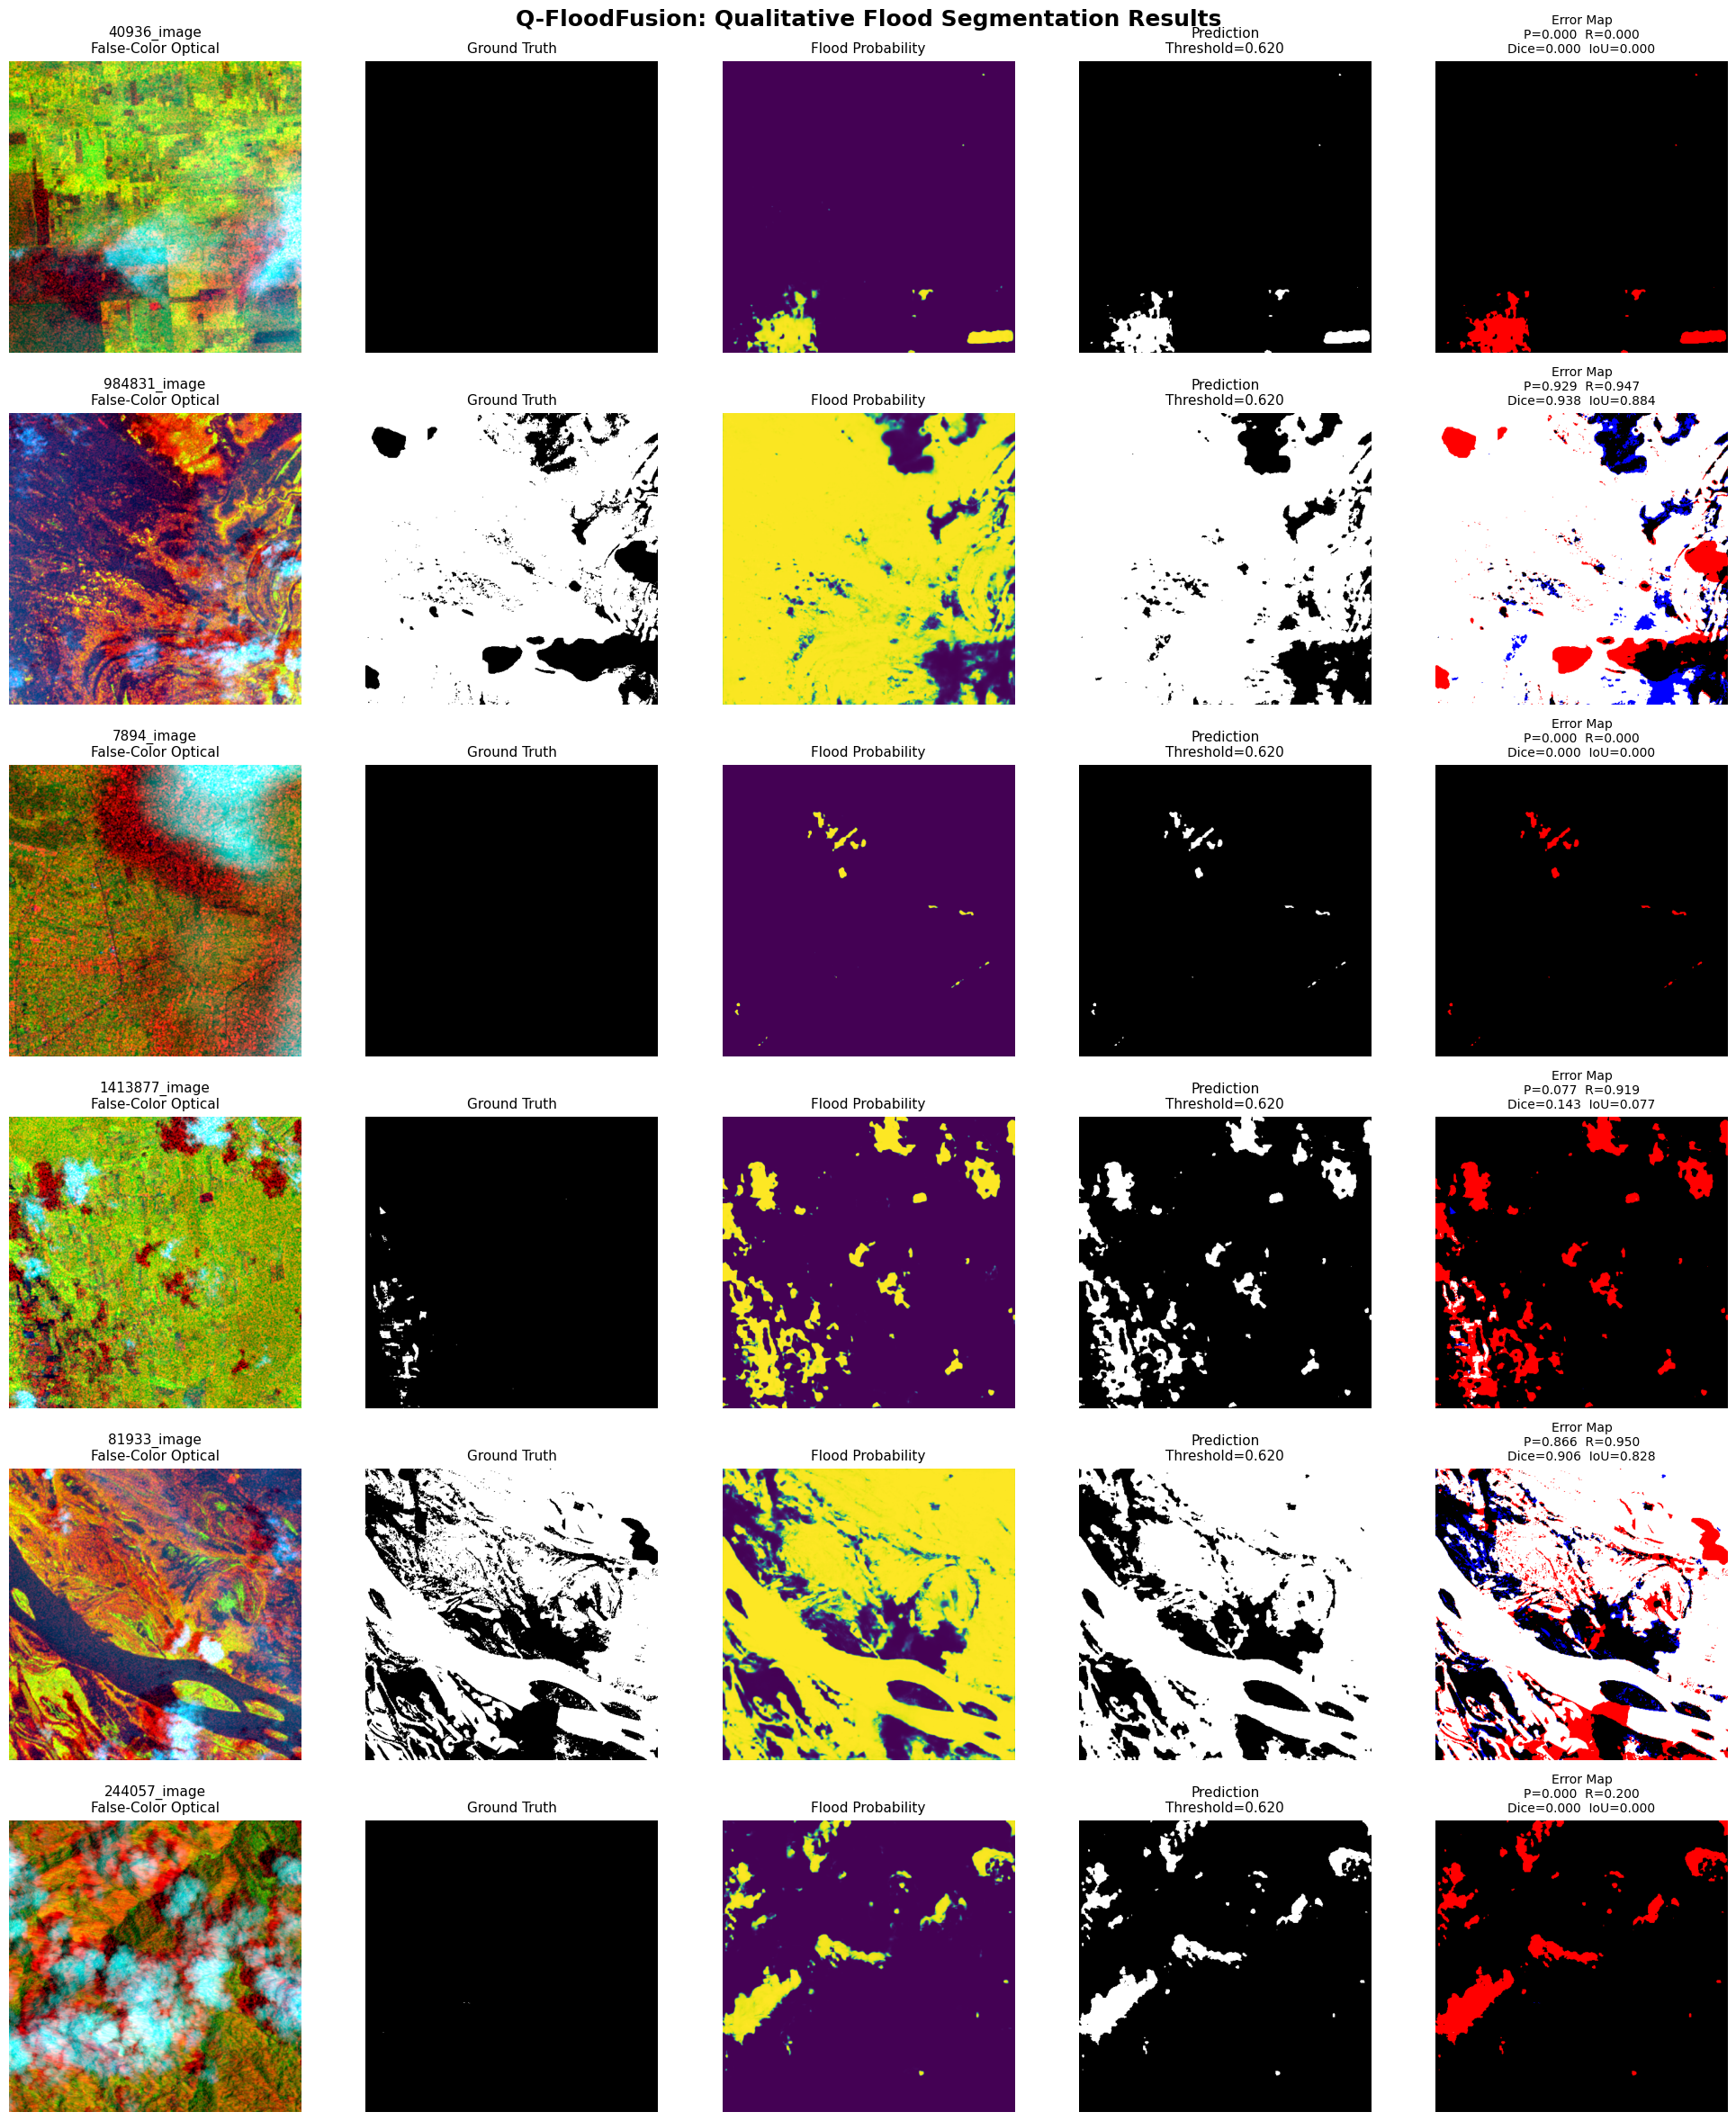


VISUALIZATION COMPLETE
Saved: /kaggle/working/Q_FloodFusion_Qualitative_Results.png


In [8]:
# ============================================================
# Q-FLOODFUSION — QUALITATIVE TEST VISUALIZATION
# SELF-CONTAINED VERSION
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODEL = model
MODEL.eval()

NUM_VISUALIZATIONS = 6

VIS_THRESHOLD = globals().get(
    "BEST_THRESHOLD",
    globals().get("best_threshold", 0.5)
)

print("=" * 80)
print("Q-FLOODFUSION — QUALITATIVE TEST VISUALIZATION")
print("=" * 80)
print(f"Prediction threshold : {VIS_THRESHOLD:.3f}")


# ============================================================
# 1. FIND / COMPUTE NORMALIZATION STATISTICS
# ============================================================

def find_existing_stats():

    possible_mean_names = [
        "train_mean",
        "channel_mean",
        "channel_means",
        "mean",
        "MEAN",
        "TRAIN_MEAN"
    ]

    possible_std_names = [
        "train_std",
        "channel_std",
        "channel_stds",
        "std",
        "STD",
        "TRAIN_STD"
    ]

    found_mean = None
    found_std = None

    for name in possible_mean_names:
        if name in globals():

            value = globals()[name]

            try:
                arr = np.asarray(value, dtype=np.float32).reshape(-1)

                if len(arr) == 8:
                    found_mean = arr
                    break

            except Exception:
                pass

    for name in possible_std_names:
        if name in globals():

            value = globals()[name]

            try:
                arr = np.asarray(value, dtype=np.float32).reshape(-1)

                if len(arr) == 8:
                    found_std = arr
                    break

            except Exception:
                pass

    return found_mean, found_std


existing_mean, existing_std = find_existing_stats()


# ------------------------------------------------------------
# IF STATISTICS ALREADY EXIST
# ------------------------------------------------------------
if existing_mean is not None and existing_std is not None:

    NORM_MEAN = existing_mean
    NORM_STD = existing_std

    print("\nUsing existing training normalization statistics.")

# ------------------------------------------------------------
# OTHERWISE COMPUTE THEM FROM TRAINING DATA
# ------------------------------------------------------------
else:

    print("\nTraining normalization statistics not found.")
    print("Computing 8-channel statistics from train_pairs...")

    if "train_pairs" not in globals():
        raise NameError(
            "train_pairs is not available. "
            "Please run the training/data-splitting cell first."
        )

    channel_sum = np.zeros(8, dtype=np.float64)
    channel_sq_sum = np.zeros(8, dtype=np.float64)
    channel_count = np.zeros(8, dtype=np.float64)

    rng = np.random.default_rng(42)

    for idx, pair in enumerate(train_pairs):

        image_path = pair[0]

        with rasterio.open(image_path) as src:
            img = src.read().astype(np.float32)

        img = np.nan_to_num(
            img,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # Sample pixels instead of using every pixel
        pixels = img.reshape(8, -1)

        n_pixels = pixels.shape[1]

        sample_size = min(
            10000,
            n_pixels
        )

        sample_indices = rng.choice(
            n_pixels,
            size=sample_size,
            replace=False
        )

        sampled = pixels[:, sample_indices]

        valid = np.isfinite(sampled)

        for c in range(8):

            values = sampled[c][valid[c]]

            if len(values) == 0:
                continue

            channel_sum[c] += values.sum()
            channel_sq_sum[c] += np.square(values).sum()
            channel_count[c] += len(values)

        if (idx + 1) % 50 == 0:
            print(
                f"Processed {idx + 1}/{len(train_pairs)} "
                f"training images"
            )

    NORM_MEAN = (
        channel_sum /
        np.maximum(channel_count, 1)
    ).astype(np.float32)

    variance = (
        channel_sq_sum /
        np.maximum(channel_count, 1)
    ) - np.square(NORM_MEAN)

    variance = np.maximum(
        variance,
        1e-8
    )

    NORM_STD = np.sqrt(
        variance
    ).astype(np.float32)

    print("\nComputed normalization statistics.")


# ------------------------------------------------------------
# DISPLAY STATISTICS
# ------------------------------------------------------------
print("\n8-CHANNEL NORMALIZATION")
print("-" * 80)

channel_names = [
    "SAR VV",
    "SAR VH",
    "Optical Green",
    "Optical Red",
    "Optical NIR",
    "Optical SWIR",
    "DEM",
    "Precipitation"
]

for i in range(8):

    print(
        f"{i}: {channel_names[i]:20s} "
        f"mean={NORM_MEAN[i]:.6f}  "
        f"std={NORM_STD[i]:.6f}"
    )


# ============================================================
# 2. LOAD RAW IMAGE + LABEL
# ============================================================

def load_raw_pair(pair):

    image_path, label_path = pair

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    with rasterio.open(label_path) as src:
        ground_truth = src.read(1).astype(np.float32)

    image = np.nan_to_num(
        image,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    ground_truth = (
        ground_truth > 0
    ).astype(np.uint8)

    return image, ground_truth


# ============================================================
# 3. FALSE-COLOR VISUALIZATION
# ============================================================

def make_false_color(img):

    # Dataset:
    # 0 = VV
    # 1 = VH
    # 2 = Green
    # 3 = Red
    # 4 = NIR
    # 5 = SWIR
    # 6 = DEM
    # 7 = Precipitation

    # NIR / Red / Green
    rgb = np.stack(
        [
            img[4],
            img[3],
            img[2]
        ],
        axis=-1
    ).astype(np.float32)

    for c in range(3):

        channel = rgb[:, :, c]

        low = np.percentile(
            channel,
            2
        )

        high = np.percentile(
            channel,
            98
        )

        if high > low:

            rgb[:, :, c] = np.clip(
                (channel - low) /
                (high - low),
                0,
                1
            )

        else:

            rgb[:, :, c] = 0

    return rgb


# ============================================================
# 4. SINGLE IMAGE PREDICTION
# ============================================================

def predict_single_raw(image):

    normalized = (
        image -
        NORM_MEAN.reshape(8, 1, 1)
    ) / (
        NORM_STD.reshape(8, 1, 1) +
        1e-8
    )

    tensor = torch.from_numpy(
        normalized.astype(np.float32)
    ).unsqueeze(0).to(DEVICE)

    with torch.inference_mode():

        output = MODEL(tensor)

        if isinstance(output, (tuple, list)):
            logits = output[0]
        else:
            logits = output

        probability = torch.sigmoid(
            logits
        )[0, 0].cpu().numpy()

    prediction = (
        probability >= VIS_THRESHOLD
    ).astype(np.uint8)

    return probability, prediction


# ============================================================
# 5. CHECK TEST DATA
# ============================================================

if "test_pairs" not in globals():

    raise NameError(
        "test_pairs is not available. "
        "Please run the training/data-splitting cell first."
    )

print(
    f"\nTest samples available : {len(test_pairs)}"
)


# ============================================================
# 6. SELECT VISUALIZATION SAMPLES
# ============================================================

visual_indices = np.linspace(
    0,
    len(test_pairs) - 1,
    min(
        NUM_VISUALIZATIONS,
        len(test_pairs)
    ),
    dtype=int
)


# ============================================================
# 7. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    len(visual_indices),
    5,
    figsize=(
        20,
        4 * len(visual_indices)
    )
)

if len(visual_indices) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )


# ============================================================
# 8. VISUALIZE EACH TEST SAMPLE
# ============================================================

for row, vis_idx in enumerate(
    visual_indices
):

    # --------------------------------------------------------
    # LOAD
    # --------------------------------------------------------

    image, ground_truth = load_raw_pair(
        test_pairs[vis_idx]
    )

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    probability, prediction = (
        predict_single_raw(image)
    )

    # --------------------------------------------------------
    # FALSE COLOR
    # --------------------------------------------------------

    false_color = make_false_color(
        image
    )

    # --------------------------------------------------------
    # SAMPLE NAME
    # --------------------------------------------------------

    sample_name = Path(
        test_pairs[vis_idx][0]
    ).stem

    # --------------------------------------------------------
    # PIXEL METRICS
    # --------------------------------------------------------

    gt = ground_truth.astype(bool)
    pred = prediction.astype(bool)

    tp = np.logical_and(
        pred,
        gt
    ).sum()

    fp = np.logical_and(
        pred,
        ~gt
    ).sum()

    fn = np.logical_and(
        ~pred,
        gt
    ).sum()

    tn = np.logical_and(
        ~pred,
        ~gt
    ).sum()

    precision = (
        tp /
        (tp + fp + 1e-8)
    )

    recall = (
        tp /
        (tp + fn + 1e-8)
    )

    dice = (
        2 * tp /
        (2 * tp + fp + fn + 1e-8)
    )

    iou = (
        tp /
        (tp + fp + fn + 1e-8)
    )

    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn + 1e-8)
    )

    # --------------------------------------------------------
    # ERROR MAP
    #
    # White = True Positive
    # Red   = False Positive
    # Blue  = False Negative
    # --------------------------------------------------------

    error_map = np.zeros(
        (*ground_truth.shape, 3),
        dtype=np.float32
    )

    error_map[
        np.logical_and(pred, gt)
    ] = [1, 1, 1]

    error_map[
        np.logical_and(pred, ~gt)
    ] = [1, 0, 0]

    error_map[
        np.logical_and(~pred, gt)
    ] = [0, 0, 1]

    # --------------------------------------------------------
    # PANEL 1
    # --------------------------------------------------------

    axes[row, 0].imshow(
        false_color
    )

    axes[row, 0].set_title(
        f"{sample_name}\nFalse-Color Optical",
        fontsize=11
    )

    axes[row, 0].axis("off")

    # --------------------------------------------------------
    # PANEL 2
    # --------------------------------------------------------

    axes[row, 1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        "Ground Truth",
        fontsize=11
    )

    axes[row, 1].axis("off")

    # --------------------------------------------------------
    # PANEL 3
    # --------------------------------------------------------

    axes[row, 2].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    axes[row, 2].set_title(
        "Flood Probability",
        fontsize=11
    )

    axes[row, 2].axis("off")

    # --------------------------------------------------------
    # PANEL 4
    # --------------------------------------------------------

    axes[row, 3].imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 3].set_title(
        f"Prediction\nThreshold={VIS_THRESHOLD:.3f}",
        fontsize=11
    )

    axes[row, 3].axis("off")

    # --------------------------------------------------------
    # PANEL 5
    # --------------------------------------------------------

    axes[row, 4].imshow(
        error_map
    )

    axes[row, 4].set_title(
        f"Error Map\n"
        f"P={precision:.3f}  "
        f"R={recall:.3f}\n"
        f"Dice={dice:.3f}  "
        f"IoU={iou:.3f}",
        fontsize=10
    )

    axes[row, 4].axis("off")

    # --------------------------------------------------------
    # PRINT SAMPLE METRICS
    # --------------------------------------------------------

    print(
        f"{sample_name:20s} | "
        f"Accuracy={accuracy:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"Dice={dice:.4f} | "
        f"IoU={iou:.4f}"
    )


# ============================================================
# 9. SAVE
# ============================================================

plt.suptitle(
    "Q-FloodFusion: Qualitative Flood Segmentation Results",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

OUTPUT_PATH = (
    "/kaggle/working/"
    "Q_FloodFusion_Qualitative_Results.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n" + "=" * 80)
print("VISUALIZATION COMPLETE")
print("=" * 80)
print(f"Saved: {OUTPUT_PATH}")